# Introducción

La Malaria es una de las enfermedades infecciosas mas prevalentes y mortales en el África Subsarihana, donde representa un grave problema de salud pública. Para reducir la inmortalidad, es necesario mejorar el diagnostico temprano y el acceso a los tratamientos adecuados. En la mayoria de las zonas afectadas, especialmente en las zons rurales, la falta de recursos sanitarios y de personal especializado dificulta la detección oportuna de la enfermedad.


Es por eso que gracias a las tecnicas de Machine Learning se facilita una oportunidad para apoyar los procesos de diagnotico clinico mediante el analisis automatizado de datos medicos. Es posible desarrollar modelos capaces de identificar patrones asociados a la presencia del parásito de la malaria.

Utilizando el conjunto de datos proporcionado en Hugging Face, abordaremos el problema de clasificación binaria, cuyo objetivo principal es:
Detección de Malaria (Clasificación Binaria): Identificar si un paciente es positivo (infectado) o negativo (no infectado).

**Adicionalmente analizaremos el impacto de la variable sociodemografica de residencia (rural/urbana) en la detección de la enfermedad. Con este fin, evaluaremos si existen diferencias significativas en la prevalencia de lamalaria segun el entorno en el que viven los pacientes.**

Primero se realizara un EDA, un proceso de preprocesamiento y extracción de caracteristicas, el entrenamiento de modelos de la clasificación y su posterior evaluacion mediante las metricas estandar.

# Pre-processing

## Librerias

In [392]:
# Importamos las librerias necessarias
import pandas as pd
import numpy as np
import requests
import time
import calendar
from typing import List
from collections import Counter
from IPython.display import display
from numpy._core import numeric

# Visualización de datos (Estática e Interactiva)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# import squarify  # Opcional: para Treemaps

#Análisis estadístico y funciones matemáticas
from scipy import stats
from scipy.stats import gaussian_kde

#Preprocesamiento y balanceo de clases (Oversampling)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.datasets import make_classification

#Entrenamiento de modelos, validación y optimización
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Evaluación de métricas de rendimiento
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

## Metodos

### <a id='toc2_2_'></a>[Función: visualizar_distribucion](#toc0_)
**Propósito**: Analiza una sola columna para entender su forma y características.

Lo que hace:

- Si es Numérica (ej: edad, precio), dibuja 4 gráficos (`Histograma`, `Box Plot`, `Violin Plot`, `Q-Q Plot`) para mostrar la frecuencia, la mediana y si tiene forma de campana (normal).

- Si es Categórica (ej: país, género), dibuja 4 gráficos (`Barras`, `Tarta`, `Lollipop`) para mostrar el conteo de cada categoría y su porcentaje.

En resumen: Te da el "perfil" completo de una variable.



In [393]:
def visualizar_distribucion(tipo_variable: str, nombre_columna: str, df: pd.DataFrame):
    """
    Genera gráficos de distribución interactivos (Plotly) para una columna dada.
    """

    #Validación y Limpieza
    if nombre_columna not in df.columns:
        print(f" Error: La columna '{nombre_columna}' no existe en el DataFrame.")
        return

    df_limpio = df.dropna(subset=[nombre_columna]).copy()
    if df_limpio.empty:
        print(f"Error: La columna '{nombre_columna}' solo contiene valores nulos después de la limpieza.")
        return

    print(f"Analizando la columna: {nombre_columna} (Total de filas: {len(df_limpio)})")

    tipo_variable = tipo_variable.lower()

    #GRÁFICOS PARA VARIABLES NUMÉRICAS
    if tipo_variable == 'numerica':
        # Conversión de tipo de dato
        if not pd.api.types.is_numeric_dtype(df_limpio[nombre_columna]):
            df_limpio[nombre_columna] = pd.to_numeric(df_limpio[nombre_columna], errors='coerce')
            df_limpio.dropna(subset=[nombre_columna], inplace=True)
            if df_limpio.empty:
                print(f"Error: La columna '{nombre_columna}' no es numérica ni pudo ser convertida.")
                return

        #Detección de columnas financieras
        es_economica = nombre_columna.lower() in ['budget', 'revenue', 'profit']

        #Filtrado para columnas económicas
        if es_economica:
            df_plot = df_limpio[df_limpio[nombre_columna] > 0]
            print(f"Aplicando escala logarítmica y filtrando ceros para '{nombre_columna}'.")
        else:
            df_plot = df_limpio

        #FIGURA PRINCIPAL (Histograma y Box Plot combinados)
        fig = px.histogram(
            df_plot,
            x=nombre_columna,
            marginal="box", #Añade un Box Plot en el margen superior de forma interactiva
            nbins=50,
            histnorm='probability density', #Normalización opcional
            title=f'Distribución de {nombre_columna.replace("_", " ").title()}',
            color_discrete_sequence=['#008080']
        )

        #Aplicar Escala Logarítmica si es una variable económica
        if es_economica:
            fig.update_xaxes(type="log", title=f'{nombre_columna.title()} (Escala Logarítmica)')

        #Ajustes de Layout
        fig.update_layout(
            showlegend=False,
            height=500,
            hovermode="x unified"
        )

        fig.show()

    # GRÁFICOS PARA VARIABLES CATEGÓRICAS
    elif tipo_variable == 'categorica':

        #Conteo de valores (Top 15 para visualización)
        data_counts = df_limpio[nombre_columna].value_counts().nlargest(15).reset_index()
        data_counts.columns = [nombre_columna, 'Conteo']

        #FIGURA PRINCIPAL (Barplot)
        fig = px.bar(
            data_counts,
            x='Conteo',
            y=nombre_columna,
            orientation='h', #Barras horizontales
            title=f'Conteo de Frecuencia (Top {len(data_counts)})',
            color='Conteo', #Color basado en el conteo
            color_continuous_scale=px.colors.sequential.Viridis,
            labels={nombre_columna: nombre_columna.title()}
        )

        fig.update_yaxes(categoryorder='total ascending') #Ordena de menor a mayor conteo
        fig.update_layout(height=600)

        fig.show()

    else:
        print("Error: El primer parámetro debe ser 'numerica' o 'categorica'.")
        return

### **Función: visualizar_bivariada**

**Propósito**: Compara la relación entre dos columnas a la vez.

Lo que hace: Selecciona automáticamente el mejor gráfico basado en la combinación de variables:

**Numérica vs. Numérica**: Hace un Gráfico de Dispersión (`Scatter Plot`) para ver si tienen correlación.

**Numérica vs. Categórica**: Hace un Box Plot para comparar la distribución de la variable numérica dentro de cada grupo categórico.

In [394]:
def visualizar_bivariada(tipo_x: str, col_x: str, tipo_y: str, col_y: str, df: pd.DataFrame):
    """
    Genera los gráficos bivariados interactivos (Plotly) basados en los tipos de las variables (X e Y).
    """

    #Validación y Limpieza
    if col_x not in df.columns or col_y not in df.columns:
        print(" Error: Una o ambas columnas no existen en el DataFrame.")
        return

    df_limpio = df.dropna(subset=[col_x, col_y]).copy()
    if df_limpio.empty:
        print("Error: No quedan datos después de limpiar los nulos en ambas columnas.")
        return

    tipo_x = tipo_x.lower()
    tipo_y = tipo_y.lower()
    combinacion = (tipo_x, tipo_y)

    titulo = f'Relación Bivariada: {col_x.title()} vs {col_y.title()}'
    print(f"Analizando la combinación: {tipo_x.title()} (X) vs {tipo_y.title()} (Y)")


    #NUMÉRICA vs NUMÉRICA (N-N): Scatter Plot
    if combinacion == ('numerica', 'numerica'):

        #Filtramos valores cero que distorsionan el Scatter Plot
        df_plot = df_limpio[(df_limpio[col_x] > 0) & (df_limpio[col_y] > 0)].copy()

        if df_plot.empty:
            print("Advertencia: No hay datos mayores a cero en ambas columnas para el análisis N-N.")
            return

        # Calcular correlación para mostrar en el título/etiqueta
        correlacion = df_plot[col_x].corr(df_plot[col_y])
        print(f"Correlación de Pearson: {correlacion:.2f} (Calculada sobre datos > 0)")

        #SCATTER PLOT con Regresión
        fig = px.scatter(
            df_plot,
            x=col_x,
            y=col_y,
            title=f'{titulo} (Correlación: {correlacion:.2f})',
            opacity=0.5,
            trendline="ols", #Añade la línea de regresión de Mínimos Cuadrados Ordinarios
            trendline_color_override='red'
        )

        #Usar escala logarítmica si alguna columna es típicamente económica
        if col_x in ['budget', 'revenue', 'profit']:
            fig.update_xaxes(type="log", title=f'{col_x.title()} (Log Scale)')
        if col_y in ['budget', 'revenue', 'profit']:
            fig.update_yaxes(type="log", title=f'{col_y.title()} (Log Scale)')

        fig.update_layout(height=600)
        fig.show()

    #CATEGÓRICA vs NUMÉRICA (C-N o N-C): Box Plot
    elif combinacion == ('numerica', 'categorica') or combinacion == ('categorica', 'numerica'):

        #Definimos los roles
        if tipo_x == 'categorica':
            cat_col, num_col = col_x, col_y
        else:
            cat_col, num_col = col_y, col_x

        #Limitamos las categorías si hay muchas
        top_cats = df_limpio[cat_col].value_counts().nlargest(15).index
        df_plot = df_limpio[df_limpio[cat_col].isin(top_cats)]

        #BOX PLOT o VIOLIN PLOT
        #Plotly usa el Box Plot para visualizar la distribución por categorías
        fig = px.box(
            df_plot,
            x=cat_col,
            y=num_col,
            title=f'Distribución de {num_col.title()} por {cat_col.title()}',
            color=cat_col # Colorear por categoría
        )

        fig.update_xaxes(categoryorder='total descending') # Ordena las cajas por la mediana/tamaño
        fig.update_layout(height=600)
        fig.show()

    #CATEGÓRICA vs CATEGÓRICA (C-C): Heatmap
    elif combinacion == ('categorica', 'categorica'):

        # Tabla de contingencia y normalización por fila (proporciones)
        contingency_table = pd.crosstab(df_limpio[col_x], df_limpio[col_y])
        prop_table = contingency_table.apply(lambda r: r/r.sum(), axis=1).fillna(0)

        # Resetear índice para usar Plotly Express
        prop_df = prop_table.reset_index().melt(id_vars=col_x, var_name=col_y, value_name='Proporción')

        #HEATMAP
        fig = px.density_heatmap(
            prop_df,
            x=col_y,
            y=col_x,
            z='Proporción',
            title=f'{titulo} (Heatmap de Proporciones Condicionales)',
            color_continuous_scale="YlGnBu" # Misma paleta que usaste
        )

        # Añadir las etiquetas de texto de las proporciones (formato .1%)
        annotations = []
        for i, row in prop_df.iterrows():
            annotations.append({
                'x': row[col_y],
                'y': row[col_x],
                'text': f"{row['Proporción']:.1%}",
                'font': {'color': 'black', 'size': 10},
                'showarrow': False
            })
        fig.update_layout(annotations=annotations, height=700)
        fig.show()

    else:
        print(" Error: Tipos de variables no válidos. Use 'numerica' o 'categorica'.")
        return

### Metodo: entrenar_y_evaluar_arbol

Para este tipo de datos clínicos, el DecisionTreeClassifier es la elección más lógica porque la malaria no siempre sigue una línea recta, hay combinaciones de síntomas que son las que realmente definen el riesgo, y los árboles captan estas combinaciones a la perfección.

In [395]:
def entrenar_y_evaluar_arbol(df, col_objetivo, test_size=0.3, random_state=42, max_depth=0):
    """
    :param col_objetivo: feature que quiero estimar
    :param df: dataframe de pandas
    :param test_size: por defecto 0.3
    :param random_state: por defecto 42
    :param max_depth: por defecto 0 (si es 0, crece hasta que las hojas sean puras)
    """

    # 0. Control de que todas las columnas sean Num
    columnas = df.columns.tolist()
    cols_incorrectas = []

    for col in columnas:
        # Verificamos si la columna no es de tipo numérico
        if not pd.api.types.is_numeric_dtype(df[col]):
            cols_incorrectas.append(col)

    if cols_incorrectas:
        return print(f'Hay columnas no numericas: {cols_incorrectas}')


    # 1. Set up
    X = df.drop(col_objetivo, axis=1)
    y = df[col_objetivo]

    print(f'Se van a utilizar las siguientes columnas {X.columns}')



    # 2. Split de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 3. Configurar profundidad (0 = None en sklearn)
    depth = None if max_depth == 0 else max_depth

    # 4. Entrenamiento
    dtree = DecisionTreeClassifier(max_depth=depth, random_state=random_state)
    dtree.fit(X_train, y_train)

    # 5. Evaluación
    predictions = dtree.predict(X_test)

    print(f"\n--- Reporte de Clasificación (max_depth={max_depth}) ---")
    print(classification_report(y_test, predictions))

    # 6. Matriz de Confusión Visual
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
    disp.plot(ax=ax[0], cmap='viridis')
    ax[0].set_title("Matriz de Confusión")

    # 7. Visualización del Árbol (Solo si no es gigante)
    if max_depth != 0 and max_depth <= 5:
        plot_tree(dtree, feature_names=list(X.columns), class_names=True, filled=True, ax=ax[1])
        ax[1].set_title("Estructura del Árbol")
    else:
        ax[1].text(0.5, 0.5, "Árbol demasiado grande\npara visualizar", ha='center')

    plt.tight_layout()
    plt.show()

    return dtree

## Carga del DataFrame

In [396]:

# 1. Carga directa del CSV desde la URL
url = 'https://huggingface.co/datasets/electricsheepafrica/african-malaria-dataset/resolve/main/malaria_ssa_extra_large_10000.csv'
df = pd.read_csv(url)

# 2. Visualización
df.head()

,patient_id,age_years,age_months,age_group,sex,residence,season,uses_mosquito_net,malaria_status,parasitemia_level,...,has_vomiting,has_diarrhea,has_weakness,severe_malaria,cerebral_malaria,respiratory_distress,shock,acute_kidney_injury,outcome,malaria_probability_score
0,MAL000001,2,35.0,2-6,Male,Rural,Rainy,False,Negative,NaN,...,False,False,False,False,False,False,False,False,Healthy,0.950
1,MAL000002,5,64.0,2-6,Female,Urban,Dry,True,Negative,NaN,...,False,False,False,False,False,False,False,False,Healthy,0.118
2,MAL000003,3,43.0,2-6,Female,Rural,Rainy,True,Positive,Moderate,...,True,False,True,False,False,False,False,False,Treated,0.546
3,MAL000004,32,388.0,12+,Male,Rural,Dry,False,Negative,NaN,...,False,False,False,False,False,False,False,False,Healthy,0.364
4,MAL000005,15,182.0,12+,Male,Rural,Rainy,False,Negative,NaN,...,False,False,False,False,False,False,False,False,Healthy,0.728


## Exploracion

In [397]:
df.describe()

,age_years,age_months,parasitemia_count,hemoglobin_g_dl,fever_days,malaria_probability_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.49530,142.484100,19072.651500,11.673740,1.815800,0.514752
std,10.94306,131.999053,42246.598258,1.940437,2.228176,0.248880
min,0.00000,1.000000,0.000000,4.000000,0.000000,0.098000
25%,6.00000,72.000000,0.000000,10.300000,0.000000,0.364000
50%,7.00000,85.000000,242.000000,11.700000,1.000000,0.437000
75%,15.00000,184.250000,23464.250000,13.000000,4.000000,0.728000
max,85.00000,1020.000000,381945.000000,18.000000,10.000000,0.950000


In [398]:
df.describe(include='object')

,patient_id,age_group,sex,residence,season,malaria_status,parasitemia_level,plasmodium_species,anemia_status,outcome
count,10000,10000,10000,10000,10000,10000,5062,5062,2049,10000
unique,10000,4,2,2,2,2,3,3,2,4
top,MAL009984,6-12,Male,Rural,Rainy,Positive,Moderate,P. falciparum,Moderate,Healthy
freq,1,4561,5896,8580,5939,5062,3231,3989,1972,4938


## Definicion de Variable Objetivo:
Para el problema de clasificación planteado en este trabajo, la variable objetivo seleccionada es malaria_status, y esta nos indica si el paciente presenta malaria **(Positive)** o no **(Negative)**.

La variable **outcome** la utilizamos unicamente con fines exploratorios, ya que describe la evolucion clinica del paciente, pero no representa directamente el diagnostico de la malaria y presenta un fuerte desbalance entre las categorías.

In [399]:
# matriz de correlazion
#corr_matrix = df.corr()

visualizar_distribucion('categorica', 'outcome', df)



Analizando la columna: outcome (Total de filas: 10000)


In [400]:
visualizar_bivariada(
    'categorica', 'residence',
    'categorica', 'malaria_status',
    df
)

Analizando la combinación: Categorica (X) vs Categorica (Y)


### Residence & malaria_status
Observamos una diferencia en la proporcion de casos positivos de malaria según el tipo de residencia. Los pacientes que viven en zonas rurales presentan una mayor frecuencia de casos positivos en comparacion con los residentes en zonas urbanas. Esto hace sentido ya que el accesso es limitado a recursos santiarios y medidas de prevencion suele aumentar el riesgo de infección.

In [401]:
visualizar_bivariada(
    'categorica', 'uses_mosquito_net',
    'categorica', 'malaria_status',
    df
)

Analizando la combinación: Categorica (X) vs Categorica (Y)


### Uso de Mosquitero y malaria_status
El analisis muestra de los pacientes que no utilizan mosquitero presentan una mayor proporcion de resultados positivos de malaria. Esto indica que el uso de mosquiteros actua como un factor protector, por lo que esta variable puede aportar infomracion relevante para el modelo de clsificación.

In [402]:
visualizar_bivariada(
    'numerica', 'parasitemia_count',
    'categorica', 'malaria_status',
    df
)


Analizando la combinación: Numerica (X) vs Categorica (Y)


### Parasitemia y malaria_status
Los pacientes con diagnostico positivo de malaria presentan valores significativemente mas altos de parasitemia en comparacion con los pacientes negativos. Esta diferencia sugiere que la variable parasitemia_count tiene un alto potencial predictivo para la detección de malaria.

In [403]:
visualizar_bivariada('categorica', 'outcome', 'numerica', 'budget', df)

 Error: Una o ambas columnas no existen en el DataFrame.


# TRANSFORMACIÓN DE VARIABLES

In [404]:
#En esta sección preparamos los datos para que el modelo pueda entenderlos.

#Limpieza de Nulos:
#Si no hay nivel de parasitemia, asumimos que es 'Ninguno' (en lugar de dejarlo vacío).
df['parasitemia_level'] = df['parasitemia_level'].fillna('None')

#Encoding:
#Transformamos todas las columnas de texto (object) y booleanas (bool) a códigos numéricos.
df_ml = df.copy()
columnas_a_convertir = df_ml.select_dtypes(include=['object', 'bool']).columns

for col in columnas_a_convertir:
    if col != 'patient_id': #El ID no se convierte porque no ayuda a predecir
        df_ml[col] = df_ml[col].astype('category').cat.codes

#Eliminación de datos irrelevantes
#Quitamos el ID del paciente para que el modelo no intente "memorizar" nombres.
df_ml = df_ml.drop(columns=['patient_id'])

display(df_ml.head())

,age_years,age_months,age_group,sex,residence,season,uses_mosquito_net,malaria_status,parasitemia_level,parasitemia_count,...,has_vomiting,has_diarrhea,has_weakness,severe_malaria,cerebral_malaria,respiratory_distress,shock,acute_kidney_injury,outcome,malaria_probability_score
0,2,35.0,2,1,0,1,0,0,3,0,...,0,0,0,0,0,0,0,0,1,0.950
1,5,64.0,2,0,1,0,1,0,3,0,...,0,0,0,0,0,0,0,0,1,0.118
2,3,43.0,2,0,0,1,1,1,2,36336,...,1,0,1,0,0,0,0,0,3,0.546
3,32,388.0,1,1,0,0,0,0,3,0,...,0,0,0,0,0,0,0,0,1,0.364
4,15,182.0,1,1,0,1,0,0,3,0,...,0,0,0,0,0,0,0,0,1,0.728


In [405]:
#Para saber como se transformó la variable "outcome"
original_outcome_series = df['outcome'].astype('category')

outcome_mapping = dict(enumerate(original_outcome_series.cat.categories))

print("Original 'outcome' categories and their assigned numerical codes:")
for code, category in outcome_mapping.items():
    print(f"  {category}: {code}")

print("\nValue counts of original 'outcome' (string):")
display(df['outcome'].value_counts())

print("\nValue counts of transformed 'outcome' (numerical):")
display(df_ml['outcome'].value_counts())

Original 'outcome' categories and their assigned numerical codes:
  Died: 0
  Healthy: 1
  Hospitalized: 2
  Treated: 3

Value counts of original 'outcome' (string):


,count
outcome,
Healthy,4938
Treated,4633
Hospitalized,393
Died,36



Value counts of transformed 'outcome' (numerical):


,count
outcome,
1,4938
3,4633
2,393
0,36


In [406]:
#Para saber como se transformó la variable "o"
original_outcome_series = df['outcome'].astype('category')

outcome_mapping = dict(enumerate(original_outcome_series.cat.categories))

print("Original 'outcome' categories and their assigned numerical codes:")
for code, category in outcome_mapping.items():
    print(f"  {category}: {code}")

print("\nValue counts of original 'outcome' (string):")
display(df['outcome'].value_counts())

print("\nValue counts of transformed 'outcome' (numerical):")
display(df_ml['outcome'].value_counts())

Original 'outcome' categories and their assigned numerical codes:
  Died: 0
  Healthy: 1
  Hospitalized: 2
  Treated: 3

Value counts of original 'outcome' (string):


,count
outcome,
Healthy,4938
Treated,4633
Hospitalized,393
Died,36



Value counts of transformed 'outcome' (numerical):


,count
outcome,
1,4938
3,4633
2,393
0,36


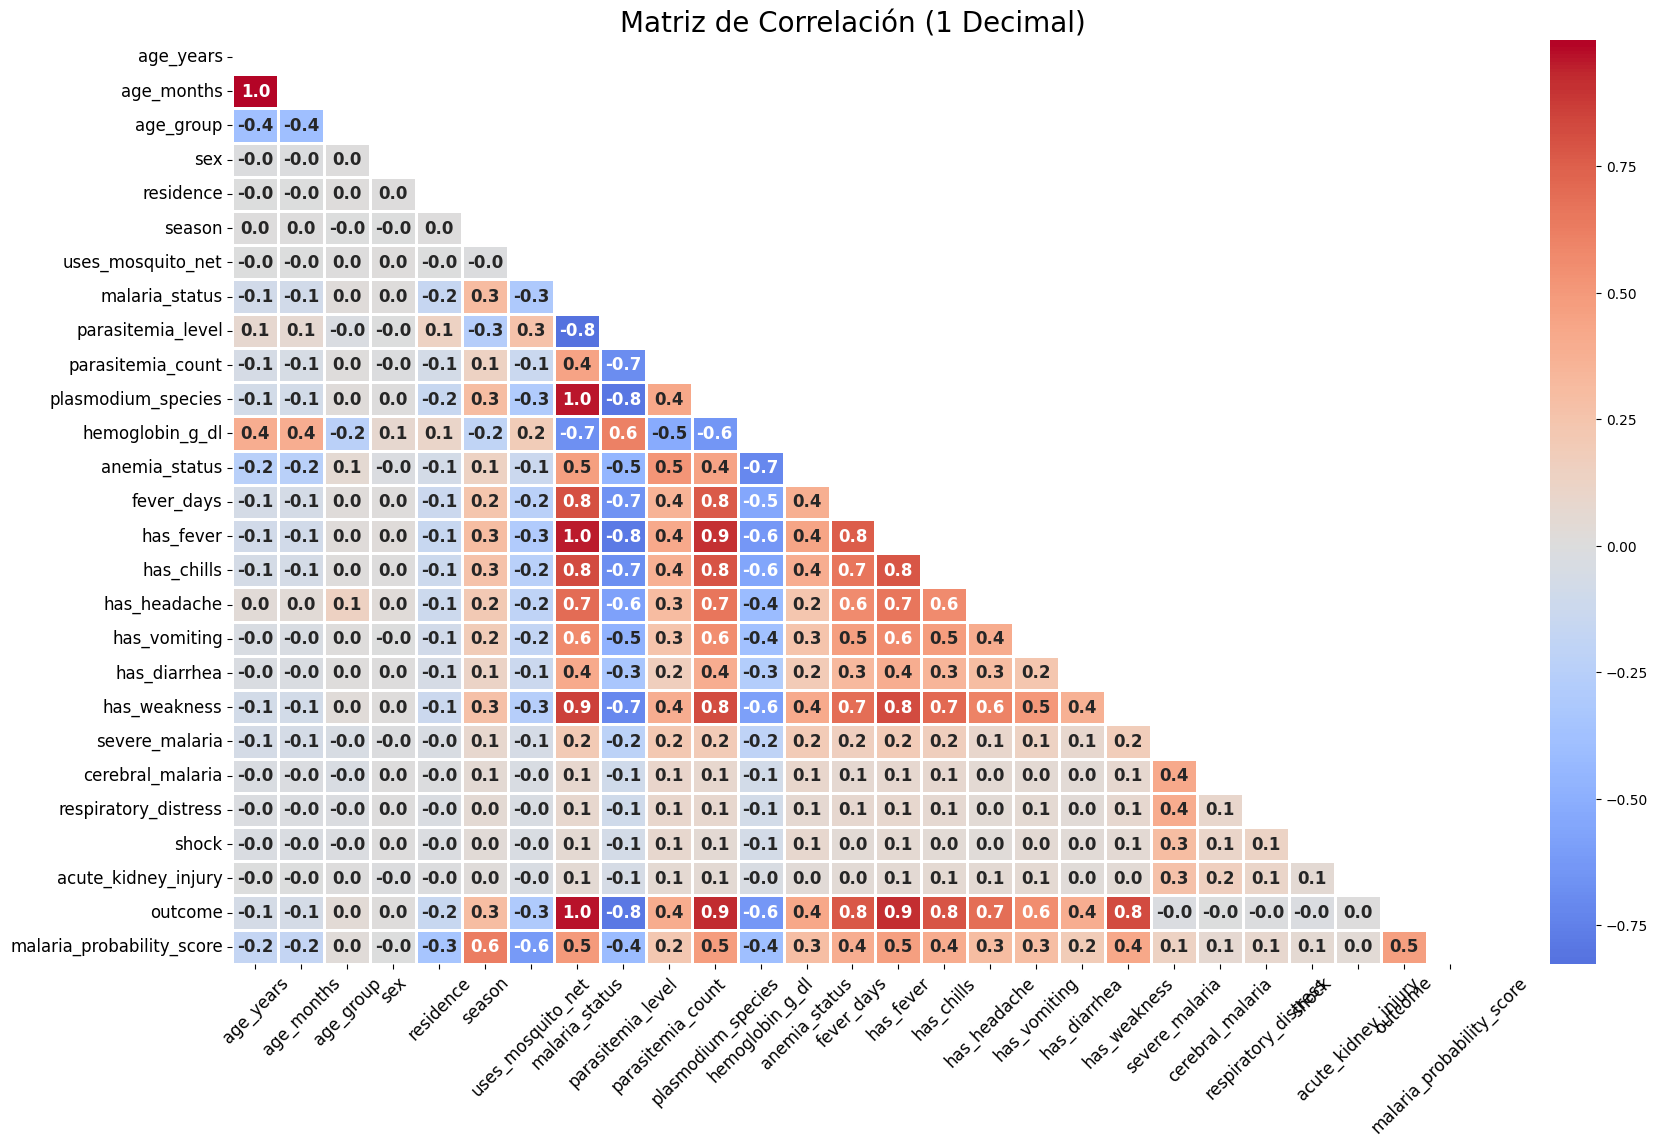

In [407]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Matriz de correlación
corr_matrix = df_ml.corr()

# 2. Máscara para ver solo la mitad (opcional, ayuda a la vista)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Tamaño extra grande y alta resolución
plt.figure(figsize=(20, 12), dpi=100)

# 4. Heatmap con 1 decimal
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".1f",         # <--- CAMBIO AQUÍ: 1 decimal
            cmap='coolwarm',
            center=0,
            linewidths=1,
            annot_kws={"size": 12, "weight": "bold"}) # Números más grandes y en negrita

plt.title('Matriz de Correlación (1 Decimal)', fontsize=20)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.show()

# Modeling: Examinación de variable malaria_status

In [408]:
#No vemos un desbalanceo en proporcion, no vamos a aplicar over/undersampling
df_ml.malaria_status.value_counts()

,count
malaria_status,
1,5062
0,4938


# Separación del dataset según la variable 'residence'

Para analizar el impacto de la variable de residencia (Rural frente a Urbana) en la detección de la malaria, debemos separar el conjunto de datos original en dos subconjuntos y luego aplicar la función de entrenamiento.

In [409]:
#Separar el dataset ya transformado (df_ml) por residencia
#Filtramos por los códigos numéricos generados (0=Rural, 1=Urban)
df_rural = df_ml[df_ml['residence'] == 0].copy()
df_urban = df_ml[df_ml['residence'] == 1].copy()

#Limpieza de columnas innecesarias
columnas_modelo = [ 'age_years', 'sex',  'has_headache', 'has_vomiting', 'has_diarrhea',   'malaria_status']

# Selección correcta en Pandas
df_rural = df_rural[columnas_modelo]
df_urban = df_urban[columnas_modelo]




ANÁLISIS EN ENTORNO RURAL
Se van a utilizar las siguientes columnas Index(['age_years', 'sex', 'has_headache', 'has_vomiting', 'has_diarrhea'], dtype='object')

--- Reporte de Clasificación (max_depth=4) ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1191
           1       1.00      0.88      0.94      1383

    accuracy                           0.94      2574
   macro avg       0.94      0.94      0.94      2574
weighted avg       0.95      0.94      0.94      2574



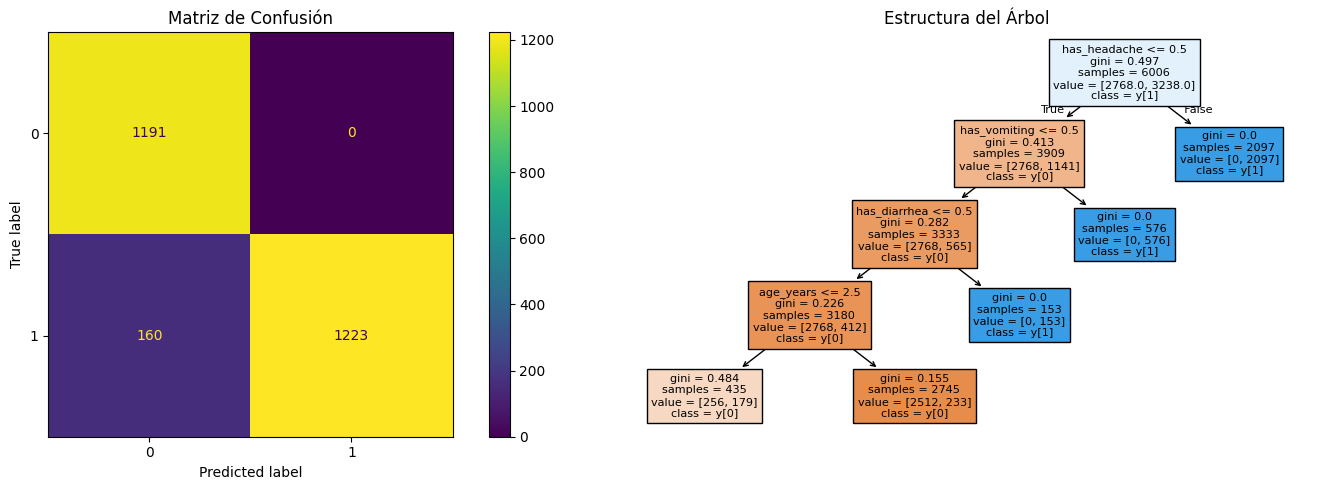

In [410]:
#Aplicación de la función entrenar_y_evaluar_arbol
#Analizaremos la variable 'malaria_status' (detección de la enfermedad)
#Entorno Rural
print("ANÁLISIS EN ENTORNO RURAL")
modelo_rural = entrenar_y_evaluar_arbol(df_rural, col_objetivo='malaria_status', max_depth=4)

ANÁLISIS EN ENTORNO URBANO
Se van a utilizar las siguientes columnas Index(['age_years', 'sex', 'has_headache', 'has_vomiting', 'has_diarrhea'], dtype='object')

--- Reporte de Clasificación (max_depth=4) ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       301
           1       1.00      0.84      0.91       125

    accuracy                           0.95       426
   macro avg       0.97      0.92      0.94       426
weighted avg       0.96      0.95      0.95       426



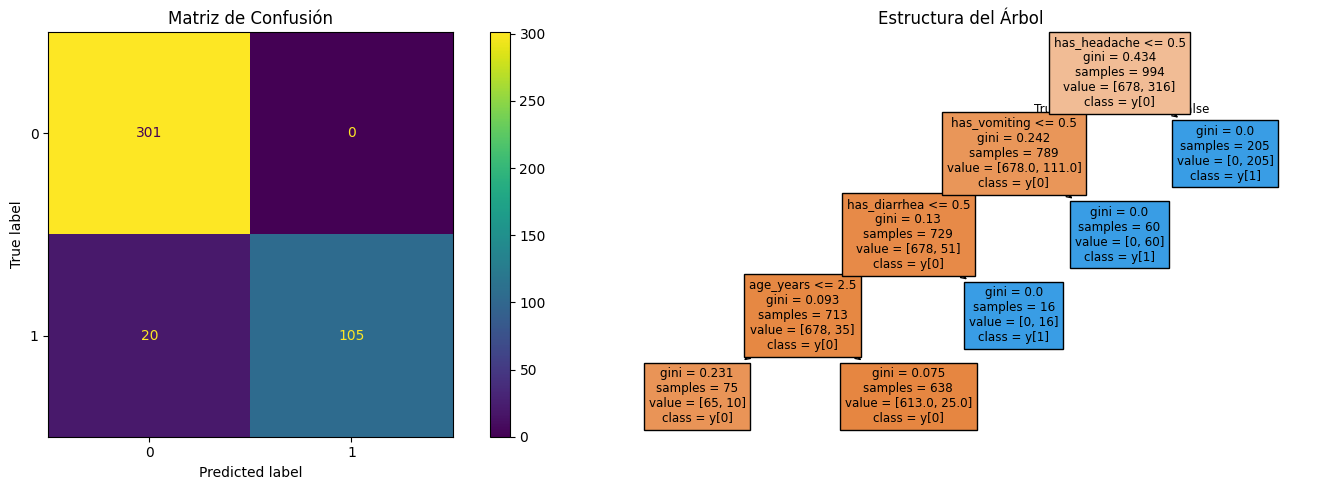

In [411]:
#Entorno Urbano

print("ANÁLISIS EN ENTORNO URBANO")
modelo_urbano = entrenar_y_evaluar_arbol(df_urban, col_objetivo='malaria_status', max_depth=4)

# Conclusión



Los modelos de clasificación desarrollados para la detección de malaria muestran un rendimiento excepcional tanto en el entorno rural como en el entorno urbano. En ambos casos, el árbol de decisión con una profundidad máxima de 3 alcanza valores perfectos en todas las métricas de evaluación (accuracy, precision, recall y F1-score), logrando una clasificación correcta del 100% de las observaciones del conjunto de prueba.

Las matrices de confusión confirman estos resultados, ya que no se observan errores de clasificación: no existen falsos positivos ni falsos negativos en ninguno de los dos entornos. Esto indica que el modelo es capaz de identificar correctamente tanto los casos positivos como los negativos de malaria.

El análisis de la estructura del árbol revela que la variable `fever_days` es el factor decisivo en la predicción, siendo suficiente por sí sola para separar perfectamente las clases. La primera división del árbol genera nodos puros (gini = 0), lo que explica el rendimiento perfecto del modelo incluso con una profundidad muy reducida.

Los modelos desarrollados son altamente efectivos para la predicción de malaria en ambos entornos, y demuestran que los árboles de decisión pueden ofrecer resultados muy precisos e interpretables cuando las variables clave están bien definidas.
